In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red">ch7. 라이브러리를 이용한 시계열 데이터 분석</font>**
- statsmodels : 통계분석을 하기 위한 라이브러리 (회귀분석, 시계열분석, 가설검정,기술통계)
    * 주기적인 데이터의 트렌드 추이
- Prophet : 계정설 추세, 휴일효과 자동으로 모델링

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈 한글 깨짐 해결
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 해결

In [5]:
# data.go.kr / 에어코리아(AirKorea) 다운로드
df = pd.read_csv('data/일별평균대기오염도_2022(에어코리아).csv', encoding='cp949')
df.tail()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
18245,20221231,구로구,0.037,0.009,0.5,0.004,43.0,29.0
18246,20221231,광진구,0.026,0.005,0.8,0.003,44.0,34.0
18247,20221231,관악산,0.008,0.038,0.3,0.005,29.0,18.0
18248,20221231,관악구,0.045,0.009,0.7,0.003,42.0,28.0
18249,20221231,공항대로,0.042,0.007,0.7,0.004,41.0,31.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18172 non-null  float64
 3   오존농도(ppm)     18176 non-null  float64
 4   일산화탄소농도(ppm)  18174 non-null  float64
 5   아황산가스농도(ppm)  18176 non-null  float64
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [24]:
# 결측치 있는 데이터
df[df['이산화질소농도(ppm)'].isna()]
df[df.isna().any(axis=1)] # 결측치가 한열이라도 있는 경우
df.loc[df.isna().any(axis=1),'측정소명'].value_counts() # 결측치가 한열이라도 있는 측정소명
# len(df.loc[df.isna().any(axis=1),'측정소명'].value_counts() ) 21개 측정소가 결측치가 있음

남산        43
동대문구      24
관악산       13
한강대로      12
시흥대로      11
북한산       11
항동         9
행주         5
마포아트센터     4
강변북로       4
서초구        3
성북구        2
송파구        2
동작대로       2
세곡         2
도산대로       2
서대문구       2
관악구        2
올림픽공원      1
은평구        1
동작구        1
Name: 측정소명, dtype: int64

In [11]:
# 서울시 측정소명들
print('측정소들 :', df['측정소명'].unique())
print('측정소 갯수 :', df['측정소명'].nunique())

측정소들 : ['강남구' '홍릉로' '행주' '항동' '한강대로' '청계천로' '천호대로' '중랑구' '중구' '종로구' '종로' '정릉로'
 '자연사박물관' '은평구' '용산구' '올림픽공원' '영등포로' '영등포구' '양천구' '신촌로' '시흥대로' '송파구' '세곡'
 '성북구' '성동구' '화랑로' '서초구' '서울숲' '서대문구' '북한산' '마포아트센터' '마포구' '동작대로' '동작구'
 '동대문구' '도산대로' '도봉구' '노원구' '남산' '금천구' '구로구' '광진구' '관악산' '관악구' '공항대로' '강서구'
 '강북구' '강변북로' '강동구' '강남대로']
측정소 갯수 : 50


In [12]:
# int형인 측정일시 컬럼을 str로
df['측정일시'] = df['측정일시'].astype(str)
df['측정일시'] = pd.to_datetime(df['측정일시'])
# df['측정일시'] = df['측정일시'].astype('datetime64[ns]')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  datetime64[ns]
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18172 non-null  float64       
 3   오존농도(ppm)     18176 non-null  float64       
 4   일산화탄소농도(ppm)  18174 non-null  float64       
 5   아황산가스농도(ppm)  18176 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 1.1+ MB


In [13]:
# 50개 측정소명을 매일 기록(그 중 결측치가 있을 수 있음)
df['측정소명'].value_counts().sort_index().index

Index(['강남구', '강남대로', '강동구', '강변북로', '강북구', '강서구', '공항대로', '관악구', '관악산', '광진구',
       '구로구', '금천구', '남산', '노원구', '도봉구', '도산대로', '동대문구', '동작구', '동작대로', '마포구',
       '마포아트센터', '북한산', '서대문구', '서울숲', '서초구', '성동구', '성북구', '세곡', '송파구',
       '시흥대로', '신촌로', '양천구', '영등포구', '영등포로', '올림픽공원', '용산구', '은평구', '자연사박물관',
       '정릉로', '종로', '종로구', '중구', '중랑구', '천호대로', '청계천로', '한강대로', '항동', '행주',
       '홍릉로', '화랑로'],
      dtype='object')

In [25]:
# 미세먼지와 초미세먼지 컬럼에 결측치가 없는 측정소명
df[df['측정소명']=='공항대로'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          365 non-null    datetime64[ns]
 1   측정소명          365 non-null    object        
 2   이산화질소농도(ppm)  365 non-null    float64       
 3   오존농도(ppm)     365 non-null    float64       
 4   일산화탄소농도(ppm)  365 non-null    float64       
 5   아황산가스농도(ppm)  365 non-null    float64       
 6   미세먼지농도(㎍/㎥)   365 non-null    float64       
 7   초미세먼지농도(㎍/㎥)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 25.7+ KB


In [26]:
loc_name = '공항대로' # 관악구는 결측치가 있는 측정소명
df_flt = df[df['측정소명']==loc_name]
df_flt.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
44,2022-01-01,공항대로,0.035,0.010,0.6,0.002,31.0,15.0
93,2022-01-02,공항대로,0.027,0.017,0.5,0.003,37.0,22.0
143,2022-01-03,공항대로,0.041,0.007,0.6,0.003,31.0,18.0
196,2022-01-04,공항대로,0.032,0.010,0.5,0.003,48.0,21.0
244,2022-01-05,공항대로,0.045,0.004,0.8,0.003,56.0,34.0


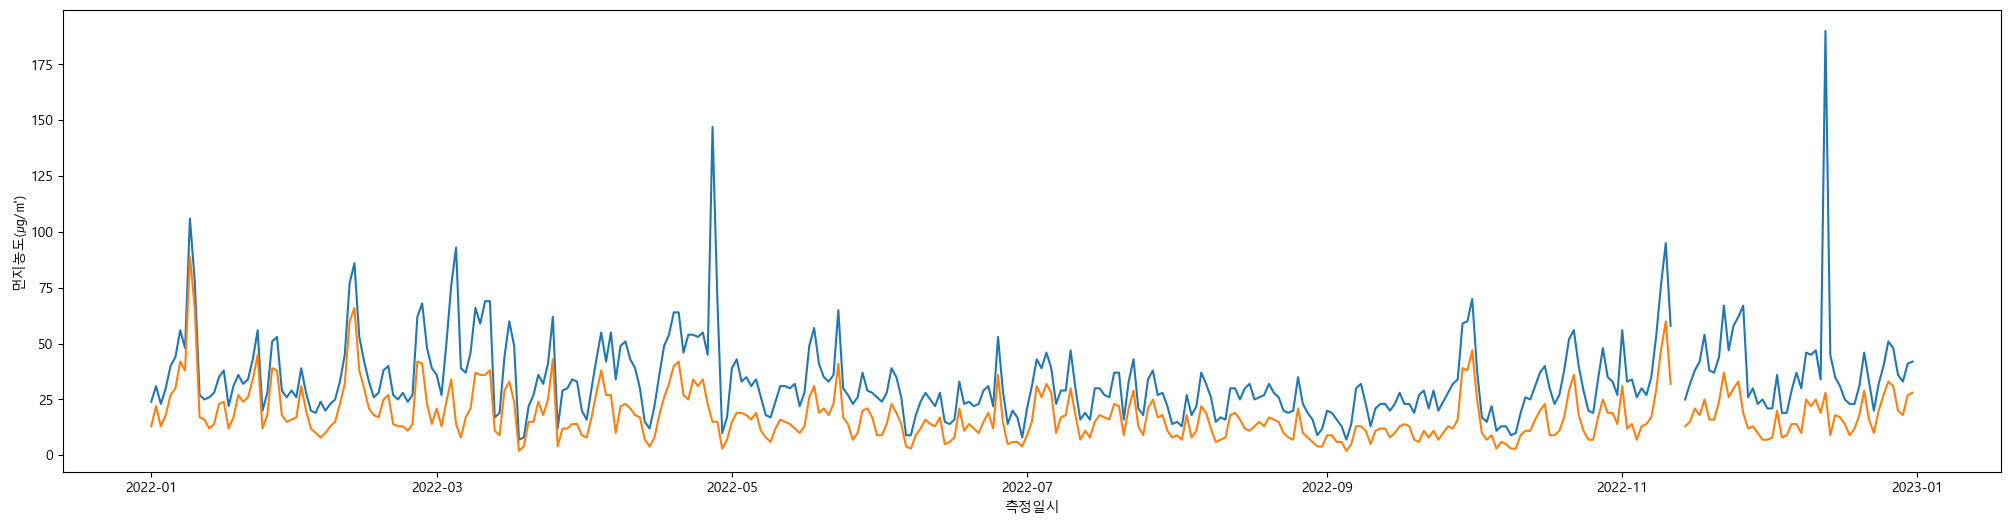

In [18]:
plt.figure(figsize=(25,6))
plt.plot(df_flt['측정일시'], df_flt['미세먼지농도(㎍/㎥)'], label='미세먼지농도')
plt.plot(df_flt['측정일시'], df_flt['초미세먼지농도(㎍/㎥)'], label='초미세먼지농도')
plt.xlabel('측정일시')
plt.ylabel('먼지농도(㎍/㎥)')
plt.show()

# statsmodels를 통한 추이 탐색
- pip install statsmodels==0.13.5
- 주기적인 데이터의 트랜드 추이
- 날짜형인덱스와 데이터 컬럼

In [28]:
df_flt2 = df_flt[['측정일시','미세먼지농도(㎍/㎥)']]
ts = df_flt2.set_index('측정일시')
ts.head()

,미세먼지농도(㎍/㎥)
측정일시,
2022-01-01,31.0
2022-01-02,37.0
2022-01-03,31.0
2022-01-04,48.0
2022-01-05,56.0


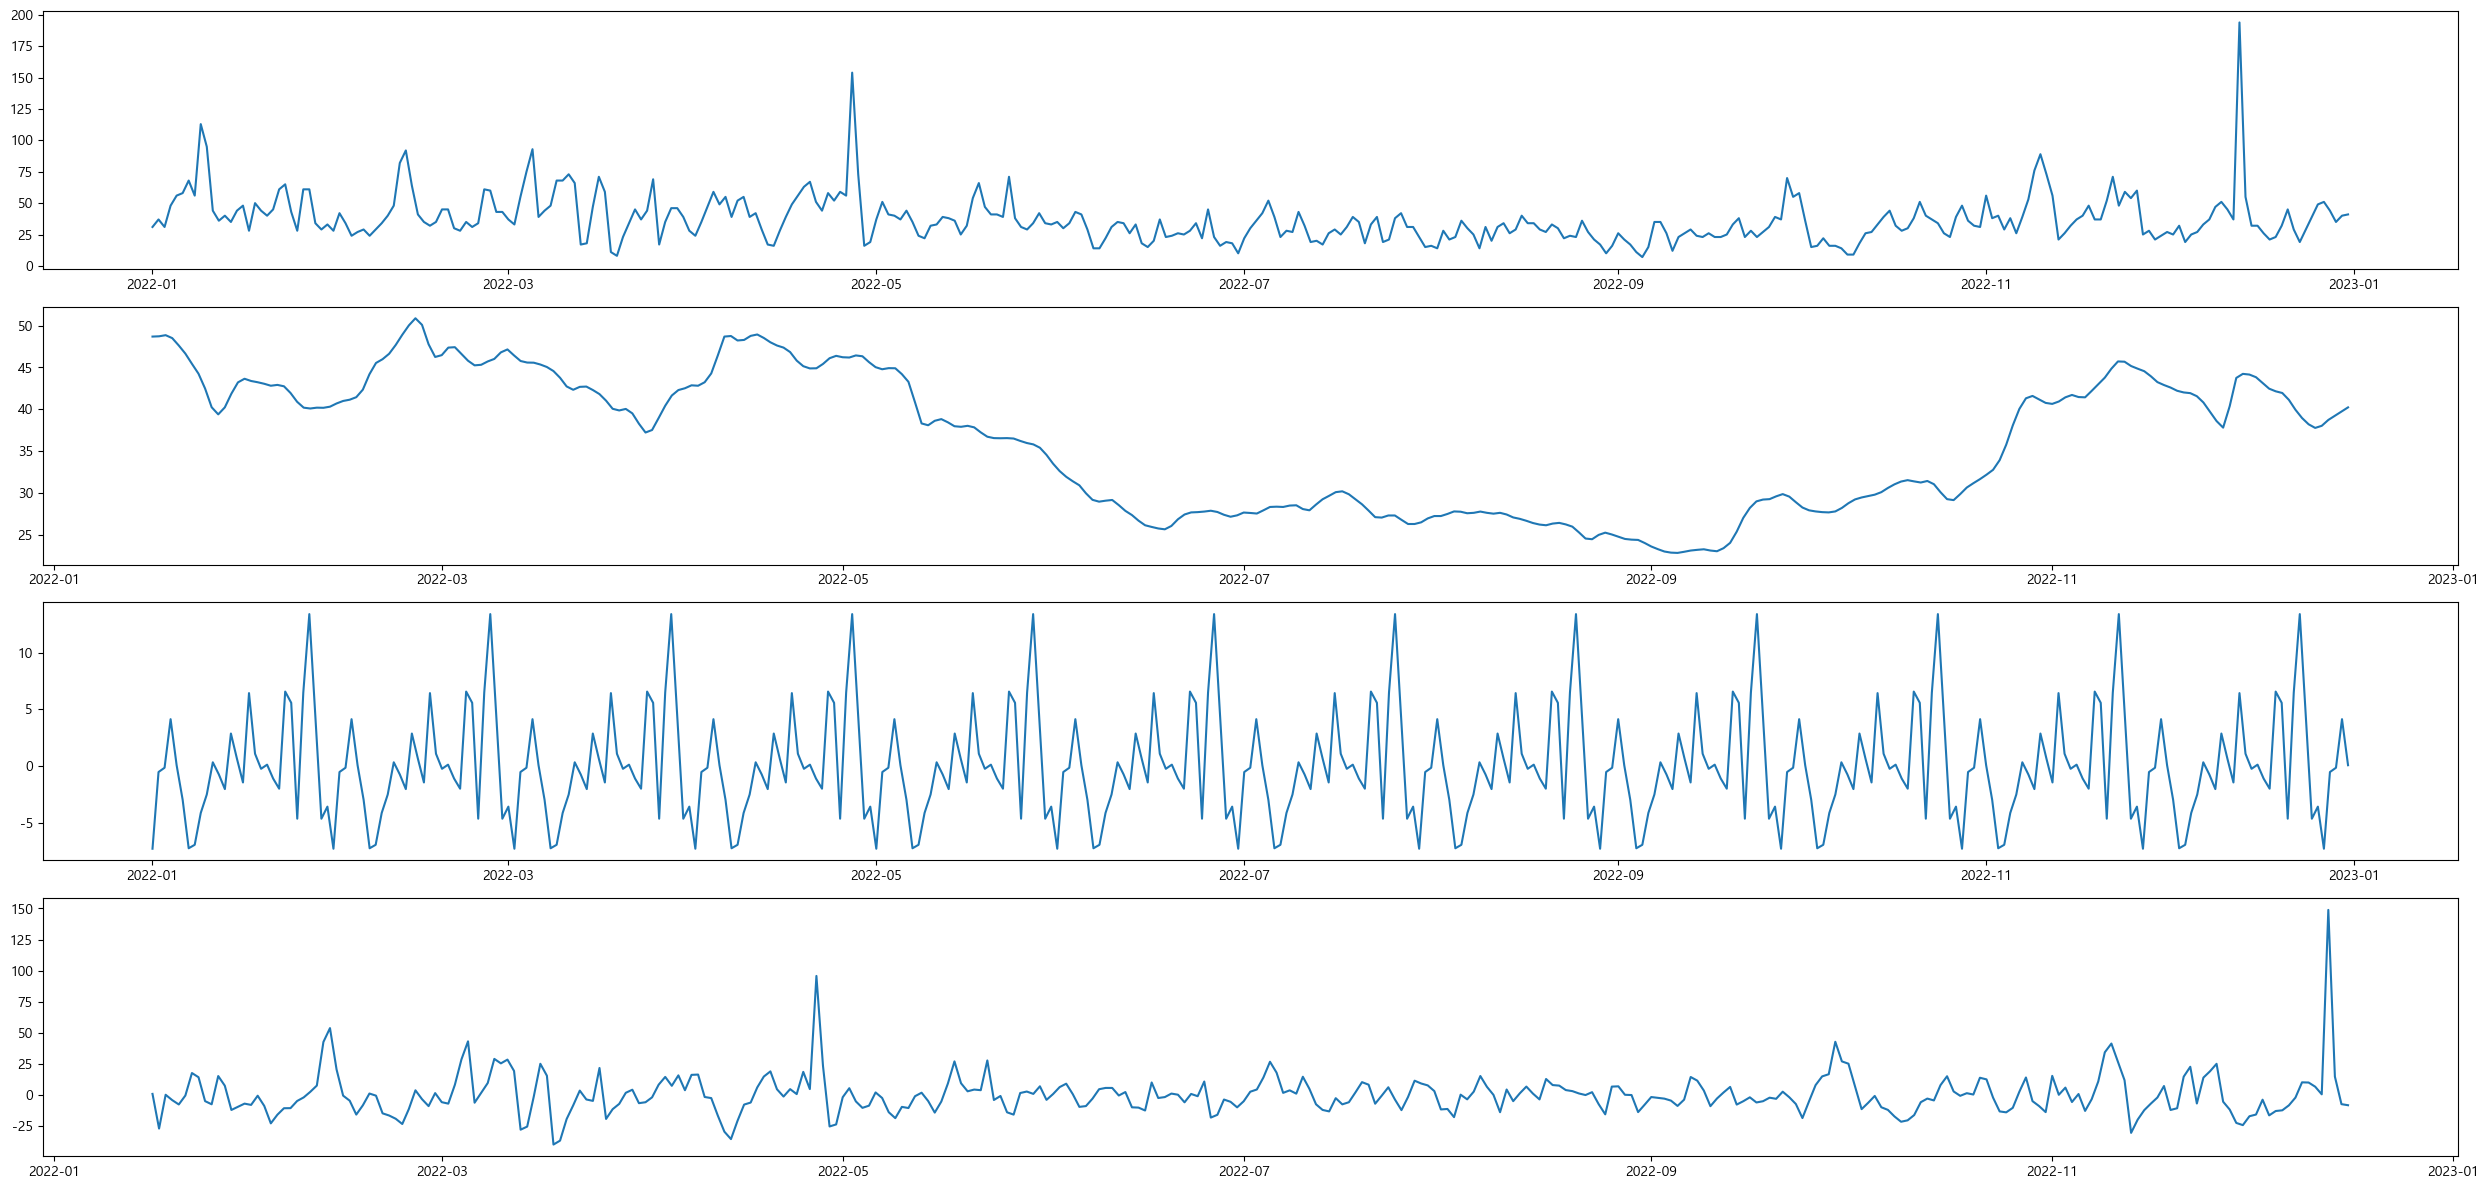

In [30]:
# 시계열 데이터의 구조를 분해해 주는 도구(statsmodels.tsa 시계열 분석 lib 패키지)
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ts['미세먼지농도(㎍/㎥)'],
                           period=30, # 30일 단위로 계절성을 분해해서 해석
                           model='additive' # "실제값 = 추세+계절성+잔차"식으로 분석
                           )
# result.observed : 실제 데이터
# result.trend # 데이터의 장기적인 변화. 전반적으로 감소, 증가
# result.seasonal # 주기적인 계절성 패턴
# result.resid # 잔차(실제값에서 추이와 계절성을 뺀 노이즈)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(25, 12))
# result.observed.plot(ax=axes[0])
# result.trend.plot(ax=axes[1])
# result.seasonal.plot(ax=axes[2])
# result.resid.plot(ax=axes[3])
axes[0].plot(result.observed)
axes[1].plot(result.trend)
axes[2].plot(result.seasonal)
axes[3].plot(result.resid)
plt.tight_layout()
plt.show()

```
seasonal_decompose & RNN/LSTM/GRU/Seq2Seq & Prophet
      통계적 추이 분석          예측               추이&예측
```

# Prophet
- 계절성, 추이, 휴일효과 등을 자동으로 모델링(facebook에서 개발한 시계열 예측 라이브러리)
- pip install prophet

In [31]:
df_flt2.sample()

,측정일시,미세먼지농도(㎍/㎥)
17394,2022-12-14,55.0


In [32]:
df_flt2.columns = ['ds', 'y'] # prophet학습시 컬럼명을 ds,y로 해야 됨
df_flt2.sample()

,ds,y
6943,2022-05-19,47.0


In [33]:
df_flt2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      365 non-null    datetime64[ns]
 1   y       365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.6 KB


In [34]:
from prophet import Prophet
# 1. 모델 생성
p_model = Prophet()
# 2. 모델 학습
p_model.fit(df_flt2)

Importing plotly failed. Interactive plots will not work.
15:25:55 - cmdstanpy - INFO - Chain [1] start processing
15:25:56 - cmdstanpy - INFO - Chain [1] done processing


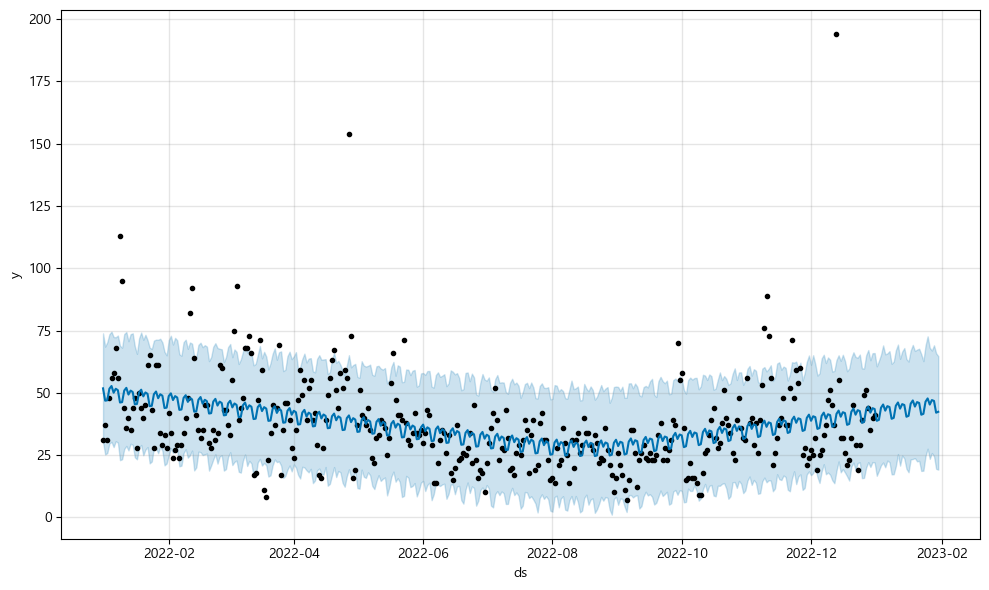

In [35]:
# p_model을 이용하여 30일 이후의 데이터를 예측하고 추이
# 3. 미래 데이터 프레임을 생성(30일 예측)
future = p_model.make_future_dataframe(periods=30)
#display(future)
# 4. 예측 수행
forecast = p_model.predict(future)
# 5. 시각화
p = p_model.plot(forecast) # 그래프를 한번만 그리려면 할당

In [36]:
forecast[['ds','yhat', 'yhat_lower', 'yhat_upper']].tail(30)
# forecast : yhat을 추세+계절성+기타요인

,ds,yhat,yhat_lower,yhat_upper
365,2023-01-01,38.760344,16.688984,60.642398
366,2023-01-02,39.131423,18.716541,62.795881
367,2023-01-03,44.001296,20.940297,65.276848
368,2023-01-04,45.309448,22.023435,69.033026
369,2023-01-05,42.843737,20.113506,65.446677
370,2023-01-06,44.648279,22.798086,65.807106
371,2023-01-07,44.295943,22.147619,66.721064
372,2023-01-08,39.573621,17.270123,61.656330
373,2023-01-09,39.944700,17.323992,62.487438
374,2023-01-10,44.814573,20.550264,67.069265


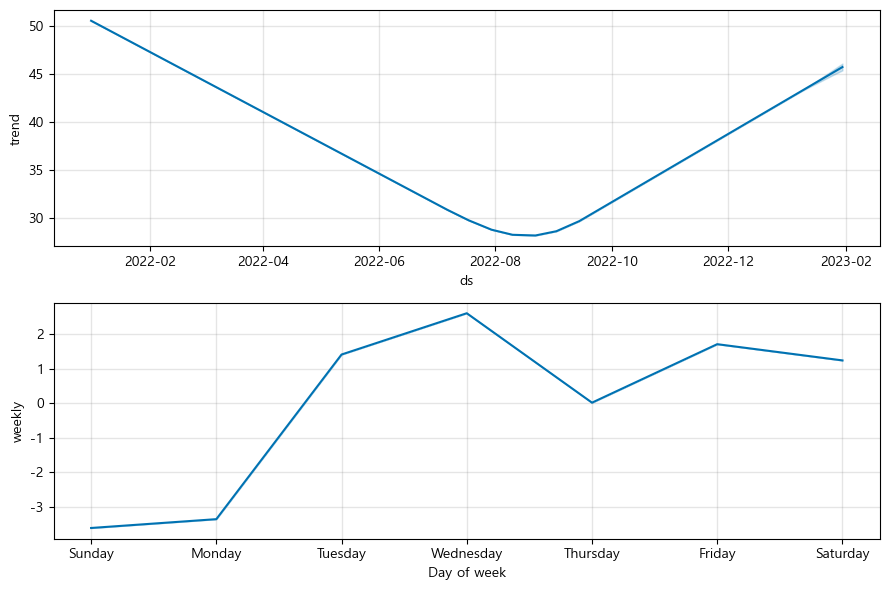

In [37]:
# 트렌드와 휴일효과 시각화
p = p_model.plot_components(forecast)

In [38]:
forecast.loc[forecast['ds']=='2023-01-15', ['yhat', 'yhat_lower', 'yhat_upper']]

,yhat,yhat_lower,yhat_upper
379,40.386897,19.511843,63.559942
